In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import seaborn as sns
from collections import Counter
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib
from matplotlib import rc

rc("text", usetex=False)
import warnings

warnings.filterwarnings("ignore")

matplotlib.rcParams['pdf.fonttype'] = 42 

# Helper function

In [2]:
def paired_line(data, lines, column1, cond1_ls, x_axis):
    plt.rcParams["figure.figsize"] = (3, 10)
    ax = sns.pointplot(x=cond1_ls, y=column1, data=data)
    sns.despine()


def non_unique(l):
    def low(x):
        return x.lower() if isinstance(x, str) else x

    c = Counter(map(low, l))
    return [x for x in l if c[low(x)] > 1]

# AgRP chemogenetics

In [3]:
data = pd.read_csv("data/chemogenetics.csv", encoding="cp1252")
data = data[
    (data["receptor"].isin(["Gq", "mCher", "hGlyR", "YFP"]))
    & (data.histology_validation != "invalid")
    & (data.histology_validation != "invalid_test")
]
data_pre = data.groupby(["receptor", "state_D2"]).size().reset_index(name="n")
data_post = data.groupby(["receptor", "state_after"]).size().reset_index(name="n")
data_pre["CNO_cond"] = "CNO-"
data_post["CNO_cond"] = "CNO+"

data_pre = data_pre.rename(columns={"state_D2": "state"})
data_post = data_post.rename(columns={"state_after": "state"})

data_t = pd.concat([data_pre, data_post], ignore_index=True)
data_t.reset_index(inplace=True)


def adding_zero_row(df):

    combinations = (
        df.groupby(["CNO_cond", "receptor"])["state"].apply(set).reset_index()
    )
    missing_rows = []
    for index, row in combinations.iterrows():
        if "Agg+" not in row["state"]:
            missing_rows.append(
                {
                    "CNO_cond": row["CNO_cond"],
                    "receptor": row["receptor"],
                    "state": "Agg+",
                    "n": 0,
                }
            )
        if "Agg-" not in row["state"]:
            missing_rows.append(
                {
                    "CNO_cond": row["CNO_cond"],
                    "receptor": row["receptor"],
                    "state": "Agg-",
                    "n": 0,
                }
            )

    # Convert the list of dictionaries to a DataFrame
    missing_df = pd.DataFrame(missing_rows)

    # Concatenate the new rows with the original DataFrame
    updated_df = pd.concat([df, missing_df], ignore_index=True)

    updated_df.sort_values(by=["CNO_cond", "receptor", "state"], inplace=True)
    updated_df.reset_index(drop=True, inplace=True)

    return updated_df


data_t = adding_zero_row(data_t)

data_count = data_t.groupby(["CNO_cond", "receptor"]).n.sum().reset_index(name="count")
data_per = data_t.merge(data_count, how="outer", on=["CNO_cond", "receptor"])
data_per["percentage"] = data_per["n"] / data_per["count"] * 100

## food intake

In [4]:
Gq_dat = data[data["receptor"].isin(["Gq"])]
stat, p = stats.ttest_rel(
    Gq_dat["food_consumption_null"], Gq_dat["food_consumption_CNO"]
)
print(p)

9.698631809291137e-05


In [5]:
def arange_drifted_bar(df, cat):
    columns = ["mice_ID", "receptor", "food_consumption_null", "food_consumption_CNO"]
    filtered_df = df[columns].reset_index(drop=True).reset_index()
    stacked_df = filtered_df[columns[-2:]].stack().reset_index()
    stacked_df.columns = ["index", "condition", "food_consumption"]
    merged_df = pd.merge(filtered_df, stacked_df, on="index")
    merged_df.receptor = pd.Categorical(merged_df.receptor, categories=cat)
    merged_df.condition = pd.Categorical(
        merged_df.condition,
        categories=["food_consumption_null", "food_consumption_CNO"],
    )
    merged_df.sort_values(["receptor", "condition"], inplace=True)
    merged_df2 = merged_df.copy()

    def encode_session(x):
        if x == "mCher" or x == "YFP":
            return 1
        else:
            return 0

    def offset_session(row):
        if row["condition"] == "food_consumption_null":
            return row["receptor"] - 0.2
        else:
            return row["receptor"] + 0.2

    merged_df2["receptor"] = merged_df2["receptor"].apply(encode_session)
    merged_df2["receptor"] = merged_df2.apply(offset_session, axis=1)

    return merged_df, merged_df2


def plot_bar(df, df2):
    plt.subplots(figsize=[2, 3])
    sns.swarmplot(
        x="receptor",
        y="food_consumption",
        hue="condition",
        data=df,
        dodge=True,
        palette=["darkgray", "Tab:orange"],
    )
    sns.barplot(
        x="receptor",
        y="food_consumption",
        hue="condition",
        data=df,
        palette=["darkgray", "Tab:orange"],
        alpha=0.7,
    )
    sns.lineplot(
        x="receptor",
        y="food_consumption",
        hue="mice_ID",
        data=df2,
        estimator=None,
        palette=["black"],
        legend=False,
        alpha=0.5,
    )
    sns.despine()

    ax = plt.gca()
    ax.set_xticks(np.arange(2), (df.receptor.unique()))
    ax.get_legend().remove()
    plt.ylabel("1h food \nconsumption(g)")
    plt.xlabel("")
    plt.savefig(
        f"output_figures/{df.receptor.unique()[0]}mchemo_food.pdf",
        dpi=300,
        bbox_inches="tight",
    )


def plot_unlinked(df, palette):
    plt.subplots(figsize=[1.7, 2])
    sns.swarmplot(
        x="receptor",
        y="food_consumption_CNO",
        data=df[df.condition == "food_consumption_CNO"],
        dodge=False,
        palette=palette,
    )
    sns.barplot(
        x="receptor",
        y="food_consumption_CNO",
        data=df[df.condition == "food_consumption_CNO"],
        palette=palette,
        alpha=0.7,
    )
    sns.despine()
    plt.ylabel("1h food \nintake(g)")
    plt.xticks(rotation=45)
    plt.xlabel("")


def ttest_ind(df, receptors):
    _, p = stats.ttest_ind(
        df[
            (df.condition == "food_consumption_CNO") & (df.receptor == receptors[0])
        ].food_consumption,
        df[
            (df.condition == "food_consumption_CNO") & (df.receptor == receptors[1])
        ].food_consumption,
    )
    return p

Gq: 7.611466963651264e-06, hGlyR: 0.008754006813114008


([0, 1, 2, 3],
 [Text(0, 0, 'Gq'),
  Text(1, 0, 'mCher'),
  Text(2, 0, 'hGlyR'),
  Text(3, 0, 'YFP')])

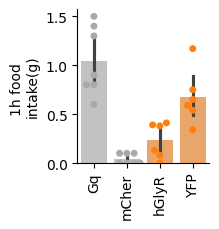

In [6]:
df_gq = data[data.receptor.isin(["Gq", "mCher"])]
df_hgly = data[data.receptor.isin(["hGlyR", "YFP"])]


df_gq, df_gq2 = arange_drifted_bar(df_gq, ["Gq", "mCher"])
df_hgly, df_hgly2 = arange_drifted_bar(df_hgly, ["hGlyR", "YFP"])
# plot_bar(df_gq, df_gq2)
# plot_bar(df_hgly, df_hgly2)

# plot_unlinked(df_gq, ['darkgray', 'darkgray'])
p_gq = ttest_ind(df_gq, ["Gq", "mCher"])

# plot_unlinked(df_hgly, ['Tab:orange', 'Tab:orange'])
p_hgly = ttest_ind(df_hgly, ["hGlyR", "YFP"])

print(f"Gq: {p_gq}, hGlyR: {p_hgly}")

agg_data = pd.concat([df_gq, df_hgly])
plot_unlinked(agg_data, ["darkgray", "darkgray", "Tab:orange", "Tab:orange"])
plt.xticks(rotation=90)

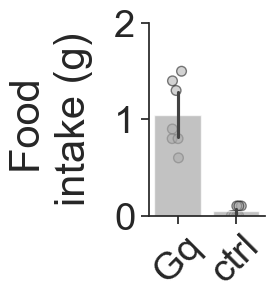

In [7]:
# CHEMOGENETIC ACTIVATION
sns.set(font_scale=2.5)
sns.set_style("ticks")
plt.subplots(figsize=[1.5, 2.5])
# sns.swarmplot(x = 'receptor', y = 'food_consumption', data = df_gq, dodge = False,
#               palette=['darkgrey', 'darkgrey'], order=['Gq', 'mCher'])
sns.stripplot(
    x="receptor",
    y="food_consumption",
    data=df_gq[df_gq.condition == "food_consumption_CNO"],
    jitter=True,
    dodge=False,
    order=["Gq", "mCher"],
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="black",
    alpha=0.5,
    zorder=0,
    palette=["darkgrey", "darkgrey"],
)
sns.barplot(
    x="receptor",
    y="food_consumption",
    data=df_gq[df_gq.condition == "food_consumption_CNO"],
    palette=["darkgrey", "darkgrey"],
    alpha=0.7,
    order=["Gq", "mCher"],
)

ax = plt.gca()
ax.set_xticklabels(("Gq", "ctrl"), rotation=45)
# ax.get_legend().remove()
plt.ylim(top=2)
plt.ylabel("Food \nintake (g)", labelpad=15)
plt.xlabel("")
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/mchemo_food.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

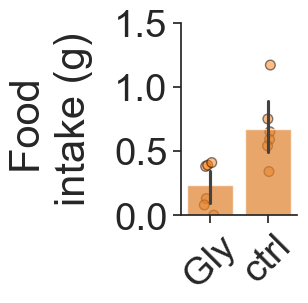

In [8]:
# CHEMOGENETIC INHIBITION
sns.set(font_scale=2.5)
sns.set_style("ticks")
plt.subplots(figsize=[1.5, 2.5])
# sns.swarmplot(x = 'receptor', y = 'food_consumption', data = df_hgly, dodge = False,
#               palette=['darkgrey', 'darkgrey'], order=['hGlyR', 'YFP'])

sns.stripplot(
    x="receptor",
    y="food_consumption",
    data=df_hgly[df_hgly.condition == "food_consumption_CNO"],
    jitter=True,
    dodge=False,
    order=["hGlyR", "YFP"],
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="black",
    alpha=0.5,
    zorder=0,
    palette=["Tab:orange", "Tab:orange"],
)
sns.barplot(
    x="receptor",
    y="food_consumption",
    data=df_hgly[df_hgly.condition == "food_consumption_CNO"],
    palette=["Tab:orange", "Tab:orange"],
    alpha=0.7,
    order=["hGlyR", "YFP"],
)


ax = plt.gca()
ax.set_xticklabels(("Gly", "ctrl"), rotation=45)
# ax.get_legend().remove()
# plt.ylim(top=1)
plt.ylabel("Food \nintake (g)", labelpad=15)
plt.xlabel("")
plt.yticks([0, 0.5, 1, 1.5])
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/hgly_food.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [9]:
test = df_hgly[df_hgly.condition == "food_consumption_CNO"]
stats.mannwhitneyu(
    test[test.receptor == "hGlyR"].food_consumption,
    test[test.receptor == "YFP"].food_consumption,
)

MannwhitneyuResult(statistic=3.0, pvalue=0.015151515151515152)

## parental behaviour

In [10]:
_, p = stats.fisher_exact([[14, 0], [39, 14]])
print(p)

0.030736867002218726


    index receptor state  n CNO_cond  count  percentage
2     6.0      YFP  Agg+  5     CNO+      6   83.333333
3     7.0      YFP  Agg-  1     CNO+      6   16.666667
4     8.0    hGlyR  Agg+  1     CNO+      7   14.285714
5     9.0    hGlyR  Agg-  6     CNO+      7   85.714286
10    1.0    hGlyR  Agg+  2     CNO-      3   66.666667
11    2.0    hGlyR  Agg-  1     CNO-      3   33.333333
Gq: (inf, 0.004662004662004662), hGlyR: (0.03333333333333333, 0.02913752913752914)


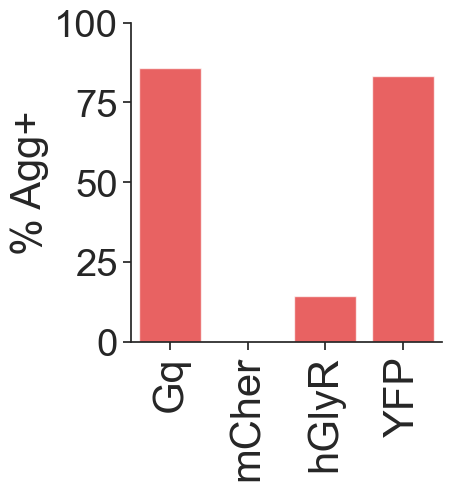

In [11]:
per_gq = data_per[data_per["receptor"].isin(["Gq", "mCher"])]
per_hgly = data_per[data_per["receptor"].isin(["hGlyR", "YFP"])]
print(per_hgly)



def plot_percentage(df, receptor, cat):
    df.receptor = pd.Categorical(df.receptor, categories=cat)

    g = sns.catplot(
        x="receptor",
        y="percentage",
        data=df[(df["state"] == "Agg+") & (df["CNO_cond"] == "CNO+")],
        kind="bar",
        alpha=0.7,
        palette=["red"],
        aspect=2 / 2,
    )

    g.set(xlabel=None)
    g.set_xticklabels(rotation=90, fontsize=30)
    g.set_ylabels(fontsize=30)
    g.set(ylabel="% Agg+")
    a1 = g.axes[0][0]

    plt.ylim([0, 100])
    sns.despine()



def fisher(df, receptors):
    df = df[df.CNO_cond == "CNO+"]
    # per_gq[(per_gq['state'] == 'Agg+') & (per_gq.receptor == 'Gq')].n

    # Extract counts for each condition
    count_agg_pos_receptor0 = df[
        (df["state"] == "Agg+") & (df.receptor == receptors[0])
    ]["n"].values[0]
    count_agg_pos_receptor1 = df[
        (df["state"] == "Agg+") & (df.receptor == receptors[1])
    ]["n"].values[0]
    count_agg_neg_receptor0 = df[
        (df["state"] == "Agg-") & (df.receptor == receptors[0])
    ]["n"].values[0]
    count_agg_neg_receptor1 = df[
        (df["state"] == "Agg-") & (df.receptor == receptors[1])
    ]["n"].values[0]

    # Create the contingency table as a list of lists
    contingency_table = [
        [count_agg_pos_receptor0, count_agg_pos_receptor1],
        [count_agg_neg_receptor0, count_agg_neg_receptor1],
    ]

    # Perform Fisher's Exact Test
    stat, p = stats.fisher_exact(contingency_table)

    return stat, p


# plot_percentage(per_gq, 'Gq', ['Gq', 'mCher'])
p_gq = fisher(per_gq, ["Gq", "mCher"])

# plot_percentage(per_hgly, 'hGlyR', ['hGlyR', 'YFP'])
p_hgly = fisher(per_hgly, ["hGlyR", "YFP"])

print(f"Gq: {p_gq}, hGlyR: {p_hgly}")

agg_data = pd.concat([per_gq, per_hgly])
plot_percentage(agg_data, "Gq_hGlyR", ["Gq", "mCher", "hGlyR", "YFP"])

(0.0, 100.0)

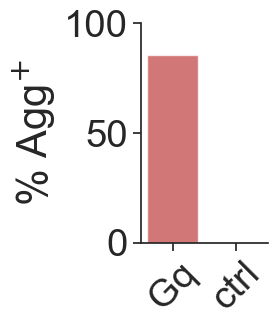

In [12]:
# CHEMOGENETIC ACTIVATION
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.catplot(
    x="receptor",
    y="percentage",
    data=per_gq.query("state == 'Agg+' and CNO_cond == 'CNO+'"),
    kind="bar",
    alpha=0.7,
    palette=["Tab:red"],
    aspect=0.85,
    height=4,
)

ax.set_xticklabels(("Gq", "ctrl"), rotation=45)
plt.ylabel(r"% Agg$^{+}$", labelpad=5)
plt.xlabel("")
plt.ylim(0, 100)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/Gq_chemo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

(0.0, 100.0)

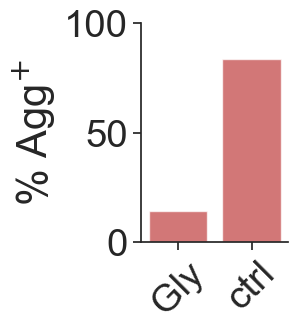

In [13]:
# CHEMOGENETIC INHIBITION
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.catplot(
    x="receptor",
    y="percentage",
    data=per_hgly.query("state == 'Agg+' and CNO_cond == 'CNO+'"),
    kind="bar",
    alpha=0.7,
    order=["hGlyR", "YFP"],
    palette=["Tab:red"],
    aspect=0.85,
    height=4,
)

ax.set_xticklabels(("Gly", "ctrl"), rotation=45)
plt.ylabel(r"% Agg$^{+}$", labelpad=5)
plt.xlabel("")
plt.ylim(0, 100)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/hgly_chemo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# optogenetics

## food intake

In [14]:
df = pd.read_csv("data/optogenetics.csv")
val = pd.read_csv("data/optogenetic_validation.csv")
df = pd.merge(df, val, on=["mice_ID", "implantation_area"])
conditions = df.pup_light_cond.dropna().unique()

           Source  ddof1  ddof2         F     p-unc       ng2       eps
0  pup_light_cond      2      8  9.549015  0.007596  0.596914  0.941227
           Source  ddof1  ddof2         F     p-unc       ng2       eps
0  pup_light_cond      2     10  2.122013  0.170544  0.213116  0.788035
           Source  ddof1  ddof2          F     p-unc       ng2       eps
0  pup_light_cond      2      8  11.306714  0.004664  0.717925  0.501547
           Source  ddof1  ddof2         F     p-unc       ng2       eps
0  pup_light_cond      2     10  8.278213  0.007571  0.559948  0.781063


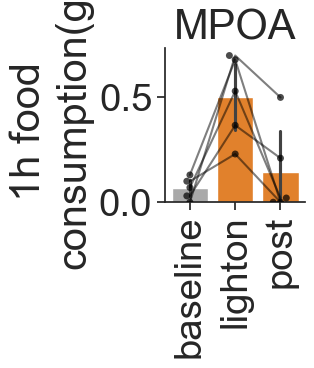

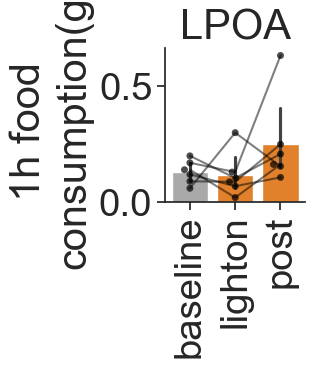

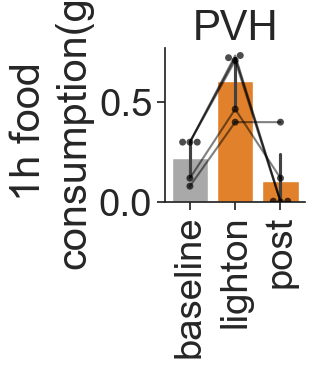

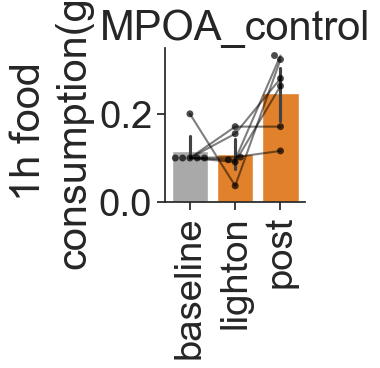

In [15]:
import pingouin as pg

for area in df.implantation_area.unique():
    food_df = df[
        (df.pup_light_cond.isin(conditions[-3:]))
        & (df.histology_validation != "invalid")
        & (df.implantation_area == area)
    ]
    food_df["status"] = pd.to_numeric(food_df.status)
    food_df["parental_status"] = pd.to_numeric(food_df.parental_status)

    food_df.pup_light_cond = pd.Categorical(
        food_df.pup_light_cond, categories=conditions[-3:], ordered=True
    )

    # repeated measures ANOVA
    model = pg.rm_anova(
        data=food_df, dv="status", within="pup_light_cond", subject="mice_ID"
    )
    # print(area, model)
    print(model)

    # post-hoc test
    posthoc = pg.pairwise_ttests(
        data=food_df,
        dv="status",
        within="pup_light_cond",
        subject="mice_ID",
        parametric=True,
    )
    # adjust p-values for multiple comparisons
    posthoc["p-corr"] = pg.multicomp(posthoc["p-unc"], method="fdr_bh")[1]
    # print(area, posthoc)

    plt.subplots(figsize=[1.8, 2])
    sns.swarmplot(
        x="pup_light_cond", y="status", data=food_df, palette=["black"], alpha=0.7
    )
    sns.barplot(
        x="pup_light_cond",
        y="status",
        data=food_df,
        palette=["darkgray", "Tab:orange", "Tab:orange"],
    )
    sns.lineplot(
        x="pup_light_cond",
        y="status",
        hue="mice_ID",
        data=food_df,
        estimator=None,
        palette=["black"],
        legend=False,
        alpha=0.5,
    )

    locs, labels = plt.xticks()
    plt.xticks(locs, (["baseline", "lighton", "post"]), rotation=90)
    plt.ylabel("1h food \nconsumption(g)")
    plt.xlabel("")
    plt.title(area)
    sns.despine()

In [16]:
## food intake latency and aggressive behaviour latency correlation
corr = pd.merge(
    df[df.pup_light_cond == "60_lighton_food"],
    df[(df.pup_light_cond == "30_lighton") & (df.implantation_area == "MPOA")],
    on=["mice_ID", "implantation_area"],
)
corr["status_x"] = pd.to_numeric(corr.status_x)
corr["parental_status_y"] = pd.to_numeric(corr.parental_status_y)
corr["parental_status_x"] = pd.to_numeric(corr.parental_status_x)
corr = corr[corr.histology_validation_x != "invalid"]

Text(93.75000000000001, 0.5, 'Attack latency(s)')

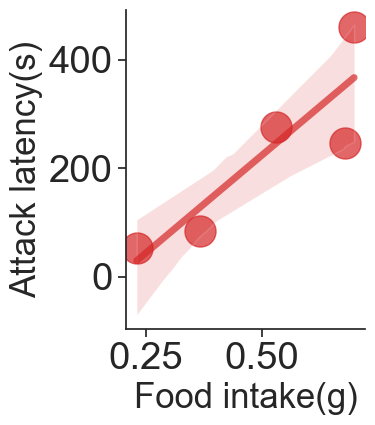

In [17]:
sns.lmplot(
    x="status_x",
    y="state_latency_y",
    data=corr,
    aspect=1.8 / 2,
    scatter_kws={"s": 500, "color": "Tab:red", "alpha": 0.7},
    line_kws={"lw": 5, "color": "Tab:red", "alpha": 0.7},
)
sns.despine()
plt.xlabel("Food intake(g)", fontsize=25)
plt.ylabel("Attack latency(s)", fontsize=25)

In [18]:
# test stats relationship
model = smf.ols("state_latency_y ~ status_x", data=corr).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        state_latency_y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     10.86
Date:                Sat, 18 Oct 2025   Prob (F-statistic):             0.0459
Time:                        12:59:34   Log-Likelihood:                -28.211
No. Observations:                   5   AIC:                             60.42
Df Residuals:                       3   BIC:                             59.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -135.0202    116.036     -1.164      0.329    -504.299     234.259
status_x     717.4315    217.670      3.296      0.046      24.709    1410.154
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.967
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.304
Skew:                          -0.240   Prob(JB):                        0.859
Kurtosis:                       1.892   Cond. No.                         6.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

([0, 1], [Text(0, 0, 'MPOA'), Text(1, 0, 'PVH')])

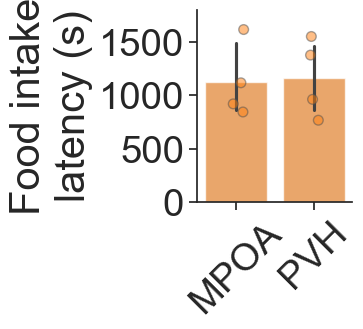

In [19]:
plt.subplots(figsize=[2, 2.5])
latency_df = df[
    (df.pup_light_cond == "60_lighton_food")
    & (df.histology_validation != "invalid")
    & (df.implantation_area.isin(["MPOA", "PVH"]))
]
sns.stripplot(
    x="implantation_area",
    y="state_latency",
    data=latency_df,
    palette=["Tab:orange", "Tab:orange"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
)
sns.barplot(
    x="implantation_area",
    y="state_latency",
    data=latency_df,
    palette=["Tab:orange", "Tab:orange"],
    alpha=0.7,
)
sns.despine()
plt.xticks(rotation=45)
plt.ylabel("Food intake\nlatency (s)")
plt.xlabel("")
sns.despine()
plt.yticks(np.arange(0, 1800, 500))
plt.ylim(0, 1800)
plt.xticks(rotation=45)


In [20]:
stats.mannwhitneyu(
    latency_df[latency_df.implantation_area == "MPOA"].state_latency.dropna(),
    latency_df[latency_df.implantation_area == "PVH"].state_latency.dropna(),
)

MannwhitneyuResult(statistic=8.0, pvalue=1.0)

## parental behaviour

In [21]:
par_df = df[
    (df.pup_light_cond.isin(conditions[:6])) & (df.histology_validation != "invalid")
]
count = (
    par_df.groupby(["implantation_area", "pup_light_cond", "status"])
    .size()
    .unstack(fill_value=0)
    .stack()
    .reset_index(name="count")
)
ns = (
    par_df.groupby(["implantation_area", "pup_light_cond"]).size().reset_index(name="n")
)
props = pd.merge(count, ns, on=["implantation_area", "pup_light_cond"])
props["props"] = props["count"] / props["n"]
props.pup_light_cond = pd.Categorical(
    props.pup_light_cond, categories=conditions[:6], ordered=True
)
props.implantation_area = pd.Categorical(
    props.implantation_area,
    categories=["MPOA", "LPOA", "PVH", "MPOA_control"],
    ordered=True,
)

In [22]:
table_df = par_df[
    (par_df.pup_light_cond.isin(["instantaneous_on", "15_lighton", "30_lighton"]))
    & (par_df.implantation_area.isin(["MPOA"]))
]
table = pd.crosstab(table_df.pup_light_cond, table_df.status)
chi, p, dof, expected = stats.chi2_contingency(table)
print(table, chi, p, dof)

status            Agg+  Agg-
pup_light_cond              
15_lighton           0     5
30_lighton           5     0
instantaneous_on     0     4 14.0 0.0009118819655545164 2


In [23]:
# import multiple comparison correction
from statsmodels.stats.multitest import multipletests
control_group = par_df[(par_df.pup_light_cond == '30_lighton') &
                       (par_df.implantation_area ==  "MPOA_control")]

all_statuses = ['Agg+', 'Agg-']
control_counts = control_group.status.value_counts().reindex(all_statuses, fill_value=0).to_frame().T


ps = []
for group in ['instantaneous_on', '15_lighton', '30_lighton']:
    table_df = par_df[
        (par_df.pup_light_cond == group)
        & (par_df.implantation_area == "MPOA")
    ]

    table = pd.crosstab(table_df.pup_light_cond, table_df.status)
    table = table.reindex(columns=all_statuses, fill_value=0)
    
    table = pd.concat([table, control_counts])
    table = table + 1  # add pseudocount
   
    print(table)
    
    F, p = stats.fisher_exact(table)
    ps.append(p)
    print(group,F, p)
# correct p values
reject, pvals_corrected, _, _ = multipletests(ps, method='fdr_bh')
print(pvals_corrected)

status            Agg+  Agg-
instantaneous_on     1     5
count                1     7
instantaneous_on 1.4 1.0
status      Agg+  Agg-
15_lighton     1     6
count          1     7
15_lighton 1.1666666666666667 1.0
status      Agg+  Agg-
30_lighton     6     1
count          1     7
30_lighton 42.0 0.0101010101010101
[1.         1.         0.03030303]


In [24]:
plot_cond = ["30_lighton"]
plot_df = props[(props.status == "Agg+") & (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(
    plot_df.pup_light_cond, categories=plot_cond, ordered=True
)
plot_df2 = plot_df.loc[
    (plot_df["implantation_area"] == "LPOA") | (plot_df["implantation_area"] == "PVH")
]
plot_df2["prob"] = plot_df2.props * 100
plot_df2

table = pd.crosstab(props.implantation_area, props.status)
table = table.reindex(columns=all_statuses, fill_value=0)
table = pd.concat([table, control_counts])
print(stats.chi2_contingency(table.loc[['LPOA', 'PVH', 'count'], :]))


Chi2ContingencyResult(statistic=4.363636363636364, pvalue=0.11283618731705683, dof=2, expected_freq=array([[2.5  , 5.5  ],
       [0.625, 1.375],
       [1.875, 4.125]]))


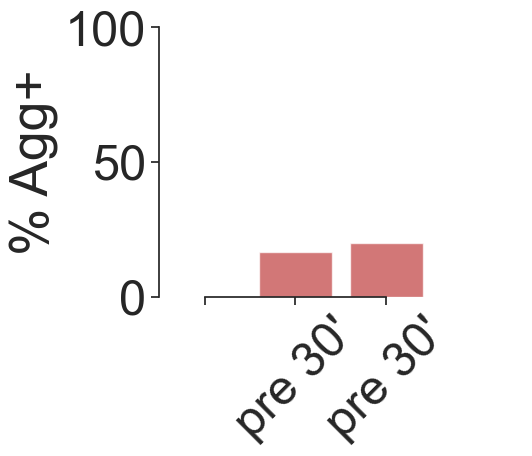

In [25]:
sns.set(rc={"figure.figsize": (2, 2)})
sns.set(font_scale=3.2)
sns.set_style("ticks")

g = sns.catplot(
    x="implantation_area",
    y="prob",
    data=plot_df2,
    kind="bar",
    alpha=0.7,
    palette=["Tab:red"],
    aspect=1.4,
)

g.set(xlabel=None)
plt.ylim([0, 100])
plt.ylabel("% Agg+")
plt.xticks(range(3))
g.set_xticklabels(("", "pre 30'", "pre 30'"), rotation=45)  # Adjust the tick labels
sns.despine(trim=True)


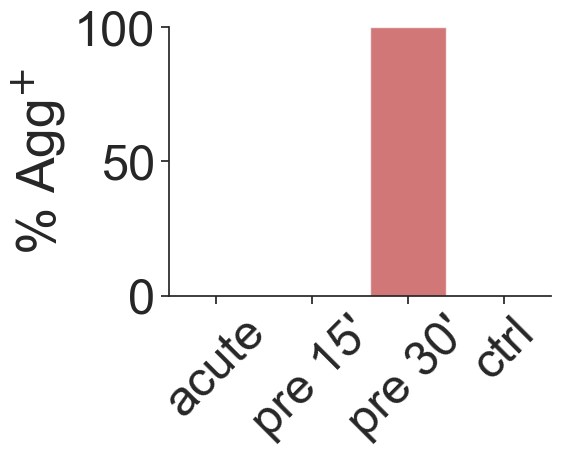

In [26]:
sns.set(rc={"figure.figsize": (2, 6)})
sns.set(font_scale=3.2)
sns.set_style("ticks")

plot_cond = ["spontaneous", "instantaneous_on", "30_lighton", "30_lightoff"]

plot_df = props[(props.status == "Agg+") & (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(
    plot_df.pup_light_cond, categories=plot_cond, ordered=True
)

plot_df["prob"] = plot_df.props * 100

g = sns.catplot(
    x="pup_light_cond",
    y="prob",
    data=plot_df[plot_df.implantation_area == "MPOA"],
    kind="bar",
    alpha=0.7,
    palette=["Tab:red"],
    aspect=1.4,
)

g.set(xlabel=None)
plt.ylim([0, 100])
plt.xticks(rotation=90)
plt.ylabel(r"% Agg$^{+}$")
g.set_xticklabels(("acute", "pre 15'", "pre 30'", "ctrl"), rotation=45)
sns.despine(trim=False)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/opto_parental.pdf",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )

In [27]:
stats.chi2_contingency(table)

Chi2ContingencyResult(statistic=4.999999999999999, pvalue=0.2872974951836458, dof=4, expected_freq=array([[4.8, 7.2],
       [3.2, 4.8],
       [0.8, 1.2],
       [0.8, 1.2],
       [2.4, 3.6]]))

# kd analysis

In [28]:
df = pd.read_csv("data/npykd.csv")
df["aggression_binary"] = df.behaviour_post.apply(lambda x: 1 if x == "Agg+" else 0)
df.loc[df.behaviour_post == "Agg-", "aggression_latency"] = 15 * 60
# check that estrous stag is not NaN

df = df[df.behaviour_post.notnull()]

valid_df = df[df.validation != "invalid"]


kd_df = valid_df[valid_df.group == "npykd"]
agrp_kd_df = valid_df[valid_df.group == "agrpkd"]
ctrl_df = valid_df[valid_df.group == "scrambled"]

In [29]:
len(kd_df.mice_ID.unique()), len(ctrl_df.mice_ID.unique())

(8, 13)

(0.0, 900.0)

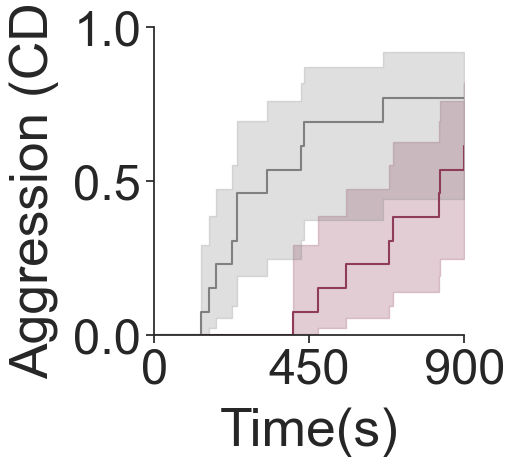

In [30]:
from lifelines import AalenJohansenFitter

# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2)
sns.set_style("ticks")
sns.set_palette(["#8F3B5A", "gray"])

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(kd_df.aggression_latency, kd_df.aggression_binary, event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency, ctrl_df.aggression_binary, event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove legend
plt.legend([], [], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time(s)", labelpad=10)
plt.ylabel("Aggression (CD)", labelpad=10)
plt.xticks(np.arange(0, 901, 450))
plt.xlim(0, 900)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/npykd.pdf',dpi=600,bbox_inches='tight', transparent=True)

Text(0.5, 1.0, ' ')

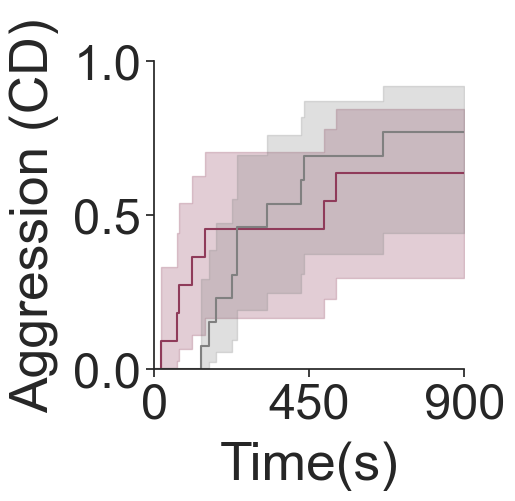

In [31]:
# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2)
sns.set_style("ticks")
sns.set_palette(["#8F3B5A", "gray"])

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(
    agrp_kd_df.aggression_latency, agrp_kd_df.aggression_binary, event_of_interest=1
)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency, ctrl_df.aggression_binary, event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend([], [], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time(s)", labelpad=10)
plt.ylabel("Aggression (CD)", labelpad=10)
plt.xticks(np.arange(0, 901, 450))
plt.xlim(0, 900)
plt.title(" ", pad = 10)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [32]:
from lifelines.statistics import logrank_test

results = logrank_test(
    kd_df.aggression_latency,
    ctrl_df.aggression_latency,
    event_observed_A=kd_df.aggression_binary,
    event_observed_B=ctrl_df.aggression_binary,
    
)
results.print_summary()
p_value_one_sided = results.p_value / 2 if results.test_statistic > 0 else 1 - (results.p_value / 2)
print(f"P-value: {p_value_one_sided} between Npy kd and ctrl")

results = logrank_test(
    agrp_kd_df.aggression_latency,
    ctrl_df.aggression_latency,
    event_observed_A=agrp_kd_df.aggression_binary,
    event_observed_B=ctrl_df.aggression_binary,
)
results.print_summary()

# get one sided p value
p_value_one_sided = results.p_value / 2 if results.test_statistic > 0 else 1 - (results.p_value / 2)

print(f"P-value: {p_value_one_sided} between Agrp kd and ctrl")

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           3.78 0.05      4.27

P-value: 0.025890409374882455 between Npy kd and ctrl


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.05 0.82      0.28

P-value: 0.4111399884423331 between Agrp kd and ctrl


In [33]:
from scipy.stats import mannwhitneyu

print(
    f"{mannwhitneyu(kd_df.aggression_latency, ctrl_df.aggression_latency)} npykd vs ctrl"
)
print(
    f"{mannwhitneyu(agrp_kd_df.aggression_latency, ctrl_df.aggression_latency)} agrpkd vs ctrl"
)

MannwhitneyuResult(statistic=132.5, pvalue=0.013449251978095541) npykd vs ctrl
MannwhitneyuResult(statistic=65.0, pvalue=0.7248907279704537) agrpkd vs ctrl


In [34]:
from glob import glob

detection_path = "npykd_detections/"
detections = glob(detection_path + "*.csv")
names = [os.path.basename(detection).split("_")[0] for detection in detections]

In [35]:
kd_cells = pd.DataFrame()
for detection, name in zip(detections, names):
    cell_num_df = pd.read_csv(detection)
    num_detection = cell_num_df[
        cell_num_df.Parent.isin(["Arcuate hypothalamic nucleus", "Median eminence"])
    ].shape[0]

    kd_cells = pd.concat(
        [
            kd_cells,
            pd.DataFrame({"mice_ID": name, "num_detection": num_detection}, index=[0]),
        ]
    )

                            OLS Regression Results                            
Dep. Variable:        state_latency_y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     10.86
Date:                Sat, 18 Oct 2025   Prob (F-statistic):             0.0459
Time:                        12:59:35   Log-Likelihood:                -28.211
No. Observations:                   5   AIC:                             60.42
Df Residuals:                       3   BIC:                             59.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -135.0202    116.036     -1.164      0.3

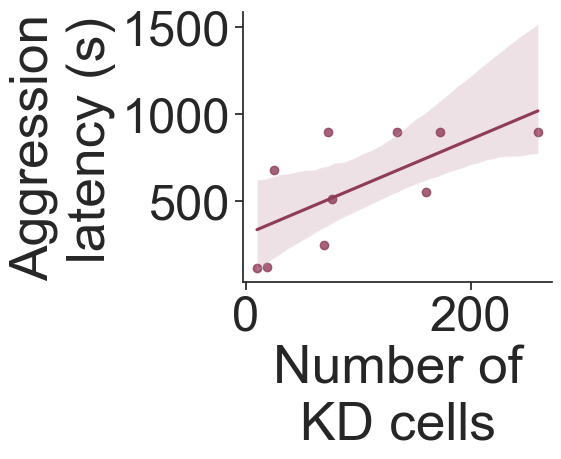

In [36]:
kd_cell_behav = pd.merge(kd_cells, df, on="mice_ID", how = 'left')
# kd_cell_behav = kd_cell_behav[kd_cell_behav.mice_ID.isin(['JKAJ33.2f', 'JKAJ30.1f', 'JKBR2.1e',  'JKBR2.1f', 'JKAJ30.2c', 'JKAJ30.2b'])]
mean_latency_cell = (
    kd_cell_behav.groupby("num_detection").aggression_latency.max().reset_index()
)


sns.lmplot(
    x="num_detection",
    y="aggression_latency",
    data=mean_latency_cell,
    height=5,
    aspect=6 / 5,
)
plt.xlabel("Number of\nKD cells")
plt.ylabel("Aggression\n latency (s)")
# plt.savefig('output_figures/npykd_cells_agg_correlation.pdf', dpi=300,bbox_inches='tight')
# plt.savefig('output_figures/npykd_cells_agg_correlation.png', dpi=300,bbox_inches='tight')
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_10/linked_figure_S10/npykd_cells_agg_correlation.pdf',dpi=600,bbox_inches='tight', transparent=True)

# test significance of the relationship
print(model.summary())

In [37]:
cleaned_df = mean_latency_cell[
    (mean_latency_cell.num_detection != 25)
    & (mean_latency_cell.num_detection != 73)
    & (mean_latency_cell.num_detection != 160)
]

0.22437723084961103


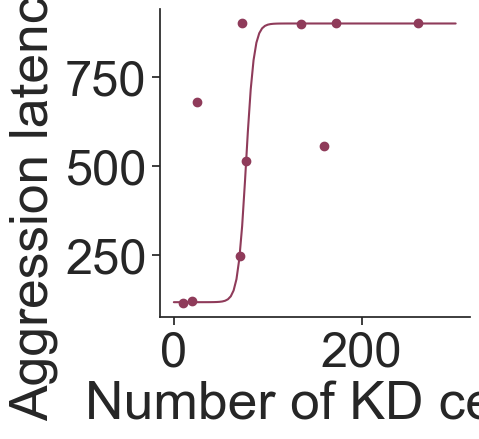

In [38]:
# curve fit to number of cells and aggression latency
from scipy.optimize import curve_fit


def logistic(x, A, x0, k, off):
    return A / (1 + np.exp(-k * (x - x0))) + off


# Initial parameter guesses and bounds
min_aggression = min(mean_latency_cell.aggression_latency)
max_aggression = max(mean_latency_cell.aggression_latency)
# Set initial parameter guesses if not yet set
initial_guess = [
    max_aggression - min_aggression,  # Amplitude starting guess
    np.median(mean_latency_cell.num_detection),  # x0 starting guess
    1,  # k starting guess
    min_aggression,  # offset starting guess
]

# Define bounds for each parameter
param_bounds = (
    [0, 0, 0, min_aggression * 0.9],  # Lower bounds for A, x0, k, off
    [
        3 * (max_aggression - min_aggression),
        np.inf,
        100,
        max_aggression * 0.9,
    ],  # Upper bounds
)
# Fit the model
popt, pcov = curve_fit(
    logistic,
    cleaned_df.num_detection,
    cleaned_df.aggression_latency,
    p0=initial_guess,
    bounds=param_bounds,
)


# popt, pcov = curve_fit(logistic, mean_latency_cell.num_detection, mean_latency_cell.aggression_latency)

# get r squared
residuals = mean_latency_cell.aggression_latency - logistic(
    mean_latency_cell.num_detection, *popt
)
ss_res = np.sum(residuals**2)
ss_tot = np.sum(
    (
        mean_latency_cell.aggression_latency
        - np.mean(mean_latency_cell.aggression_latency)
    )
    ** 2
)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)


x = np.linspace(0, 300, 100)
y = logistic(x, *popt)
plt.plot(x, y)
plt.scatter(mean_latency_cell.num_detection, mean_latency_cell.aggression_latency)
plt.xlabel("Number of KD cells")
plt.ylabel("Aggression latency(s)")
sns.despine()

Text(0, 0.5, 'Cumulative density')

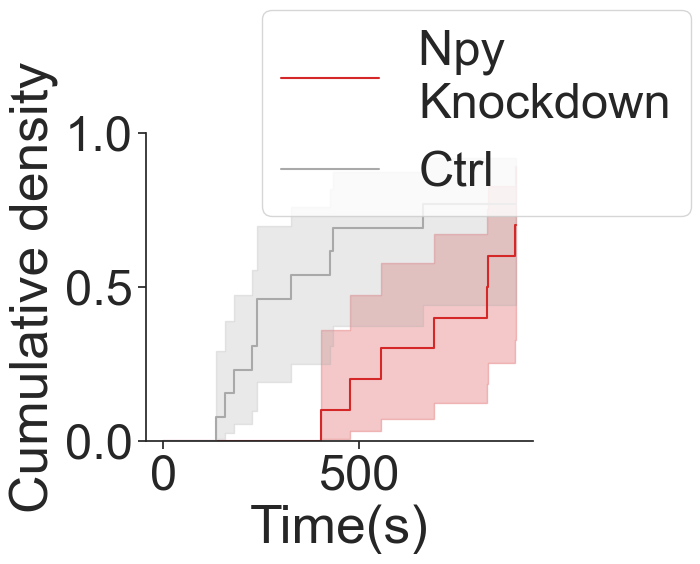

In [40]:
id_invalid = kd_cell_behav[kd_cell_behav.num_detection < 100].mice_ID
kd_df = kd_df[~kd_df.mice_ID.isin(id_invalid)]

from lifelines import AalenJohansenFitter

# change palette to orange and gray
sns.set_palette(["Tab:red", "darkgray"])
plt.rcParams["figure.figsize"] = (5, 4)

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(kd_df.aggression_latency, kd_df.aggression_binary, event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency, ctrl_df.aggression_binary, event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
plt.legend(
    handles[::],
    ["Npy \nKnockdown", "Ctrl"],
    bbox_to_anchor=(0.3, 1.4),
    loc="upper left",
    borderaxespad=0.0,
)
# remove top and right spines
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time(s)")
plt.ylabel("Cumulative density")

In [41]:
from lifelines.statistics import logrank_test

results = logrank_test(
    kd_df.aggression_latency,
    ctrl_df.aggression_latency,
    event_observed_A=kd_df.aggression_binary,
    event_observed_B=ctrl_df.aggression_binary,
)
results.print_summary()

# Checking the direction of the effect (Z statistic)
z_stat = results.test_statistic
p_value_two_sided = results.p_value

print("two side p-value:", p_value_two_sided)

# Determine direction for one-sided test:
# Assuming we want to test if 'kd' group has higher event rate than 'ctrl' group
if z_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print("One-sided p-value:", p_value_one_sided)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.19 0.14      2.84

two side p-value: 0.1392910632640209
One-sided p-value: 0.06964553163201045


## food intake npykd

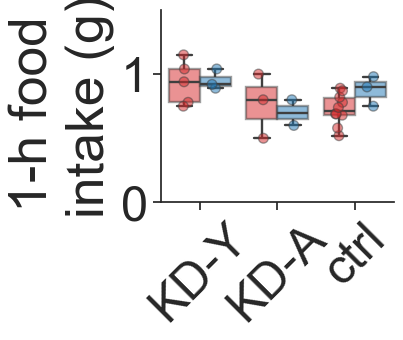

In [42]:
plt.subplots(figsize=[3, 2.5])
ax = sns.stripplot(
    x="group",
    y="food_intake",
    hue="behaviour_post",
    data=df[df.group != "ctrl"],
    palette=["Tab:red", "Tab:blue"],
    jitter=True,
    dodge=True,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    order=["npykd", "agrpkd", "scrambled"],
    alpha=0.5,
)
sns.boxplot(
    x="group",
    y="food_intake",
    hue="behaviour_post",
    data=df[df.group != "ctrl"],
    palette=["Tab:red", "Tab:blue"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    order=["npykd", "agrpkd", "scrambled"],
    boxprops=dict(alpha=0.5),
)
plt.xticks(rotation=45)
plt.xticks([0, 1, 2], ["KD-Y", "KD-A", "ctrl"])
plt.ylim([0, 1.5])
plt.ylabel("1-h food \nintake (g)")
ax.legend_.remove()
plt.xlabel("")
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_10/linked_figure_S10/npykd_food.pdf',dpi = 300,bbox_inches='tight', transparent=True)

In [43]:
# two way anova
for group in ["npykd", "agrpkd", "scrambled"]:
    sub_df = df[df.group == group]
    print(stats.mannwhitneyu(
        sub_df[sub_df.behaviour_post == "Agg+"].food_intake.dropna(),
        sub_df[sub_df.behaviour_post == "Agg-"].food_intake.dropna(),
    ))


MannwhitneyuResult(statistic=7.5, pvalue=1.0)
MannwhitneyuResult(statistic=3.5, pvalue=1.0)
MannwhitneyuResult(statistic=4.0, pvalue=0.07552433448990362)


In [44]:
stats.ttest_ind(
    df[df.group == "npykd"].food_intake.dropna(),
    df[df.group == "scrambled"].food_intake.dropna(),
)

TtestResult(statistic=2.9767471276682356, pvalue=0.007750335348038223, df=19.0)

In [45]:
stats.ttest_ind(
    df[df.group == "agrpkd"].food_intake.dropna(),
    df[df.group == "scrambled"].food_intake.dropna(),
)

TtestResult(statistic=-0.26322992125835687, pvalue=0.7957331324346063, df=16.0)

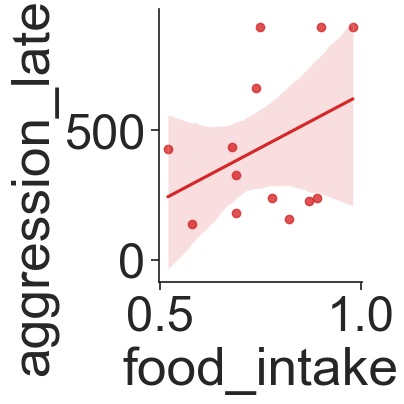

In [46]:
sns.lmplot(
    x="food_intake",
    y="aggression_latency",
    data=df[df.group == "scrambled"],
    aspect=2 / 2,
)

                            OLS Regression Results                            
Dep. Variable:     aggression_latency   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     1.670
Date:                Sat, 18 Oct 2025   Prob (F-statistic):              0.223
Time:                        12:59:35   Log-Likelihood:                -91.059
No. Observations:                  13   AIC:                             186.1
Df Residuals:                      11   BIC:                             187.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -184.4402    490.371     -0.376      

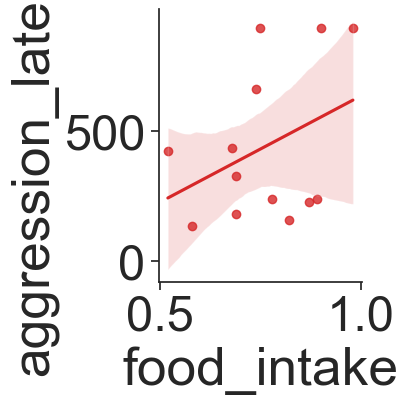

In [47]:
sns.lmplot(
    x="food_intake",
    y="aggression_latency",
    data=valid_df[valid_df.group == "scrambled"],
    aspect=2 / 2,
)
results = (
    smf.ols(
        "aggression_latency ~ food_intake", data=valid_df[valid_df.group == "scrambled"]
    )
    .fit()
    .summary()
)
print(results)

## knockdown quantification

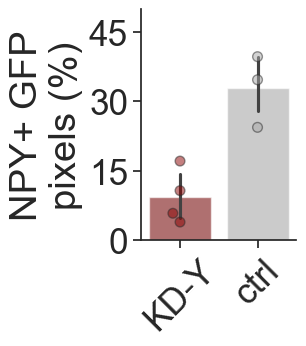

In [50]:
quan_df = pd.read_csv("data/npykd_validation.csv")
quan_df["npykd_neurons_with_npy"] = quan_df["npykd_neurons_with_npy"] * 100
sns.set(font_scale=2.3, style="ticks")
fig, ax = plt.subplots(figsize=[2, 3])
sns.barplot(
    x="condition",
    y="npykd_neurons_with_npy",
    data=quan_df,
    palette=["darkred", "darkgray"],
    alpha=0.6,
)
sns.swarmplot(
    x="condition",
    y="npykd_neurons_with_npy",
    data=quan_df,
    palette=["darkred", "darkgray"],
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
)
plt.xticks(rotation=45)
plt.xticks([0, 1], ["KD-Y", "ctrl"])
plt.ylim([0, 50])

ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.ylabel("NPY+ GFP\npixels (%)")
plt.xlabel("")
sns.despine()

In [51]:
from scipy.stats import ttest_ind

ttest_ind(
    quan_df[quan_df.condition == "npykd"].npykd_neurons_with_npy,
    quan_df[quan_df.condition == "scrambled"].npykd_neurons_with_npy,
)

TtestResult(statistic=-4.588803224554373, pvalue=0.005900029401038867, df=5.0)

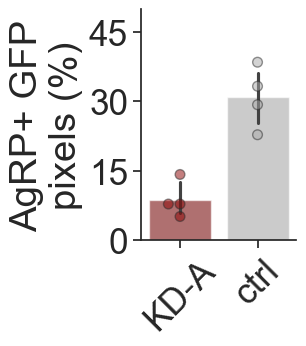

In [53]:
# agrp quantification
quan_df = pd.read_csv("data/agrpkd_validation.csv")
valid_df = quan_df[quan_df.validation == 'valid']

valid_df["agrpkd_neurons_with_agrp"] = valid_df["agrpkd_neurons_with_agrp"] * 100
sns.set(font_scale=2.3, style="ticks")
fig, ax = plt.subplots(figsize=[2, 3])
sns.barplot(
    x="condition",
    y="agrpkd_neurons_with_agrp",
    data=valid_df,
    order = ["agrpkd", "scrambled"],
    palette=["darkred", "darkgray"],
    alpha=0.6,
)
sns.swarmplot(
    x="condition",
    y="agrpkd_neurons_with_agrp",
    data=valid_df,
    order= ["agrpkd", "scrambled"],
    palette=["darkred", "darkgray"],
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
)
plt.xticks(rotation=45)
plt.xticks([0, 1], ["KD-A", "ctrl"])
plt.ylim([0, 50])

ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.ylabel("AgRP+ GFP\npixels (%)")
plt.xlabel("")
sns.despine()

In [54]:
from scipy.stats import ttest_ind

ttest_ind(
    valid_df[valid_df.condition == "agrpkd"]['agrpkd_neurons_with_agrp'],
    valid_df[valid_df.condition == "scrambled"]['agrpkd_neurons_with_agrp']
)

TtestResult(statistic=-5.8016888710268715, pvalue=0.0011497018039985853, df=6.0)

# cannulation experiments

In [55]:
cann_df = pd.read_csv("data/cannulation.csv")

cann_df["agg_state"] = pd.Categorical(
    cann_df["agg_state"], categories=["Agg+", "Agg-"], ordered=True
)

cann_df = cann_df[cann_df.validation != "invalid"]

per_df = cann_df.groupby(["condition", "agg_state"]).size().reset_index(name="n")
per_df = per_df.merge(
    cann_df.groupby("condition").size().reset_index(name="count"), on="condition"
)
per_df["percentage"] = per_df["n"] / per_df["count"] * 100

Text(0.5, 0, '')

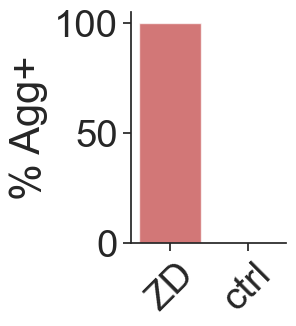

In [56]:
sns.set(font_scale=2.5)
sns.set_style("ticks")
plt.subplots(figsize=[2, 3])
ax = sns.barplot(
    x="condition",
    y="percentage",
    data=per_df[per_df.agg_state == "Agg+"],
    alpha=0.7,
    palette=["Tab:red"],
    order=["ZD7288", "ACSF"],
)
sns.despine()
# set x ticks labels
ax.set_xticklabels(["ZD", "ctrl"])
plt.xticks(rotation=45)

plt.ylabel("% Agg+")
plt.xlabel("")
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/cannulation.pdf', dpi=300,bbox_inches='tight', transparent=True)

In [57]:
# perform fisher test
cann_df = cann_df[cann_df.condition.isin(["ZD7288", "ACSF"])]
table = pd.crosstab(cann_df.condition, cann_df.agg_state)
f,p = stats.fisher_exact(table)
print(f,p)

0.0 0.007936507936507938


In [59]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    cann_df[cann_df.condition == "ZD7288"].food_consumption.dropna(),
    cann_df[cann_df.condition == "ACSF"].food_consumption.dropna(),
)

MannwhitneyuResult(statistic=3.0, pvalue=0.22169999376487637)

Text(0.5, 0, '')

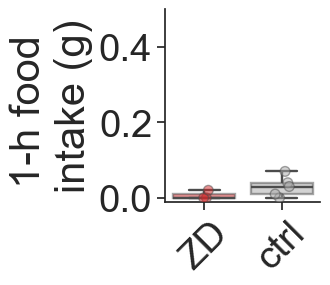

In [60]:
plt.subplots(figsize=[2, 2.5])
sns.boxplot(
    x="condition",
    y="food_consumption",
    data=cann_df,
    order=["ZD7288", "ACSF"],
    palette=["Tab:red", "darkgray"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    boxprops=dict(alpha=0.5),
)
sns.stripplot(
    x="condition",
    y="food_consumption",
    data=cann_df,
    order=["ZD7288", "ACSF"],
    palette=["Tab:red", "darkgray"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
)
sns.despine()
plt.xticks([0, 1], ["ZD", "ctrl"], rotation=45)
plt.yticks(np.arange(0, 0.5, 0.2))
plt.ylim([-0.01, 0.5])
plt.ylabel("1-h food \nintake (g)")
plt.xlabel("")
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_10/linked_figure_S10/cannulation_food.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

(0.0, 900.0)

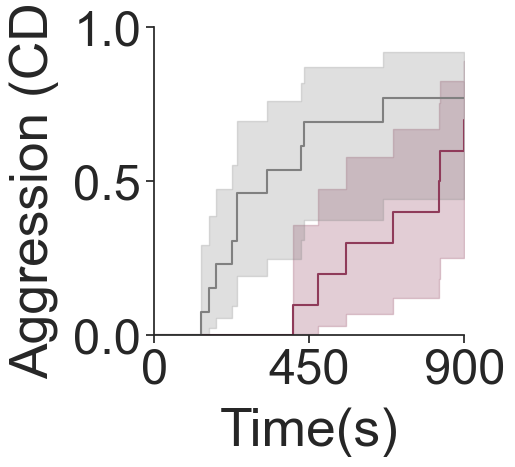

In [61]:
# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2)
sns.set_style("ticks")
sns.set_palette(["#8F3B5A", "gray"])

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(kd_df.aggression_latency, kd_df.aggression_binary, event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency, ctrl_df.aggression_binary, event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove legend
plt.legend([], [], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time(s)", labelpad=10)
plt.ylabel("Aggression (CD)", labelpad=10)
plt.xticks(np.arange(0, 901, 450))
plt.xlim(0, 900)
# plt.savefig('output_figures/npykd.pdf', dpi=300,bbox_inches='tight')
# plt.savefig('output_figures/npykd.png', dpi=300,bbox_inches='tight')
#
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/npykd.pdf',dpi=600,bbox_inches='tight', transparent=True)

# manipulation latency

In [62]:
latency = pd.read_csv("data/manipulation_latency.csv")
latency = latency[latency.validation != "invalid"].dropna(subset=["latency"])

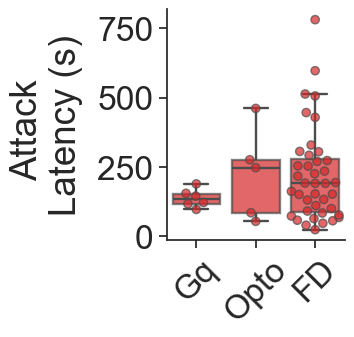

In [63]:
sns.set(font_scale=2.2, style="ticks")
fig, ax = plt.subplots(figsize=[2.3, 3])
sns.boxplot(
    x="manipulation",
    y="latency",
    data=latency[latency.manipulation != "ZD"],
    palette=["Tab:red"],
    boxprops=dict(alpha=0.7),
    saturation=8,
    linewidth=1.7,
    showfliers=False,
)
sns.swarmplot(
    x="manipulation",
    y="latency",
    data=latency[latency.manipulation != "ZD"],
    palette=["Tab:red"],
    dodge=False,
    marker="o",
    size=6,
    linewidth=1,
    edgecolor="gray",
    alpha=0.7,
)
plt.xticks(rotation=45)
plt.xticks([0, 1, 2], ["Gq", "Opto", "FD"])

ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.ylabel("Attack \nLatency (s)", labelpad=10)
plt.xlabel("")
sns.despine()

In [64]:
# one way ANOVA
model = smf.ols("latency ~ manipulation", data=latency).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# post-hoc test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison

mc = MultiComparison(latency["latency"], latency["manipulation"])
result = mc.tukeyhsd()
print(result)

                    sum_sq    df         F   PR(>F)
manipulation  9.955326e+04   3.0  1.350651  0.26838
Residual      1.253030e+06  51.0       NaN      NaN
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1    group2  meandiff p-adj    lower    upper   reject
-------------------------------------------------------------
30_lighton       Gq    -87.2  0.795 -339.2739 164.8739  False
30_lighton       ZD   -145.2 0.5169 -424.4534 134.0534  False
30_lighton food_dep   -5.325 0.9999  -202.787  192.137  False
        Gq       ZD    -58.0 0.9396 -326.7117 210.7117  False
        Gq food_dep   81.875 0.6339 -100.3741 264.1241  False
        ZD food_dep  139.875 0.3334  -78.4274 358.1774  False
-------------------------------------------------------------


In [65]:
latency.groupby("manipulation").latency.mean()

manipulation
30_lighton    224.700
Gq            137.500
ZD             79.500
food_dep      219.375
Name: latency, dtype: float64

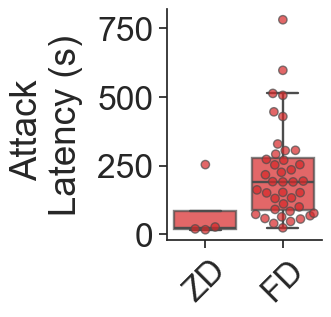

In [66]:
sns.set(font_scale=2.2, style="ticks")
fig, ax = plt.subplots(figsize=[2, 3])
sns.boxplot(
    x="manipulation",
    y="latency",
    data=latency[latency.manipulation.isin(["ZD", "food_dep"])],
    palette=["Tab:red"],
    boxprops=dict(alpha=0.7),
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    order=["ZD", "food_dep"],
)

sns.swarmplot(
    x="manipulation",
    y="latency",
    data=latency[latency.manipulation.isin(["ZD", "food_dep"])],
    palette=["Tab:red"],
    dodge=False,
    marker="o",
    size=6,
    linewidth=1,
    edgecolor="gray",
    alpha=0.7,
    order=["ZD", "food_dep"],
)

plt.xticks(rotation=45)
plt.xticks([0, 1], ["ZD", "FD"])

ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.ylabel("Attack \nLatency (s)", labelpad=10)
plt.xlabel("")
sns.despine()


In [67]:
stats.mannwhitneyu(
    latency[latency.manipulation == "ZD"].latency.dropna(),
    latency[latency.manipulation == "food_dep"].latency.dropna(),
)

MannwhitneyuResult(statistic=28.5, pvalue=0.03732301611517399)

In [68]:
latency["aggression_binary"] = latency.state_after.apply(
    lambda x: 1 if x == "Agg+" else 0
)
latency.loc[latency.state_after == "Agg-", "latency"] = 15 * 60
# check that estrous stag is not NaN
latency = latency[latency.state_after.notnull()]

cannulation_df = latency[latency.manipulation == "ZD"]
ctrl_df = latency[latency.manipulation == "food_dep"]

Text(0.5, 1.0, '\n')

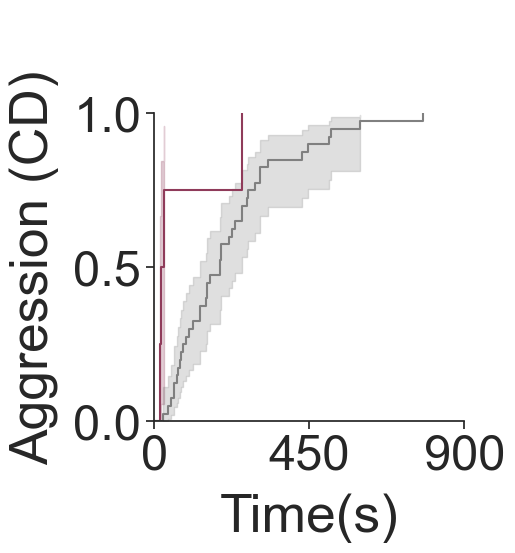

In [69]:
from lifelines import AalenJohansenFitter

# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2)
sns.set_style("ticks")
sns.set_palette(["#8F3B5A", "gray"])

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(cannulation_df.latency, cannulation_df.aggression_binary, event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.latency, ctrl_df.aggression_binary, event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove legend
plt.legend([], [], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0, 1])
plt.xlabel("Time(s)", labelpad=10)
plt.ylabel("Aggression (CD)", labelpad=10)
plt.xticks(np.arange(0, 901, 450))
plt.xlim(0, 900)
plt.title("\n")


In [70]:
from lifelines.statistics import logrank_test

results = logrank_test(
    cannulation_df.latency,
    ctrl_df.latency,
    event_observed_A=cannulation_df.aggression_binary,
    event_observed_B=ctrl_df.aggression_binary,
)
results.print_summary()

# Checking the direction of the effect (Z statistic)
z_stat = results.test_statistic
p_value_two_sided = results.p_value

print("two side p-value:", p_value_two_sided)

# Determine direction for one-sided test:
# Assuming we want to test if 'kd' group has higher event rate than 'ctrl' group
if z_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print("One-sided p-value:", p_value_one_sided)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           4.96 0.03      5.26

two side p-value: 0.026012780615957253
One-sided p-value: 0.013006390307978627
